CNN MODEL EVALUATION

Model found:
E:\Major_project\AI-Based-Intelligent-RF-Spectrum-Signal-Identification-System-main\models\best_cnn_modulation_classifier.keras

Loading test data...
Test data loaded successfully.

X_test shape: (44000, 2, 128)
y_test shape: (44000,)
Number of classes: 11

CNN test input shape:
(44000, 2, 128, 1)

Loading trained CNN model...
Trained model loaded successfully.

GENERATING PREDICTIONS
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

Predictions generated successfully.
Prediction shape: (44000,)

OVERALL TEST ACCURACY
Overall Accuracy: 56.43%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        8PSK     0.6191    0.4853    0.5441      4000
      AM-DSB     0.5596    0.7175    0.6288      4000
      AM-SSB     0.2649    0.9535    0.4146      4000
        BPSK     0.8507    0.5982    0.7025      4000
       CPFSK     0.9072    0.5985    0.7212      4000
        GFSK     0.8609    0.6498    0.7406      4000
        PAM4     0.924

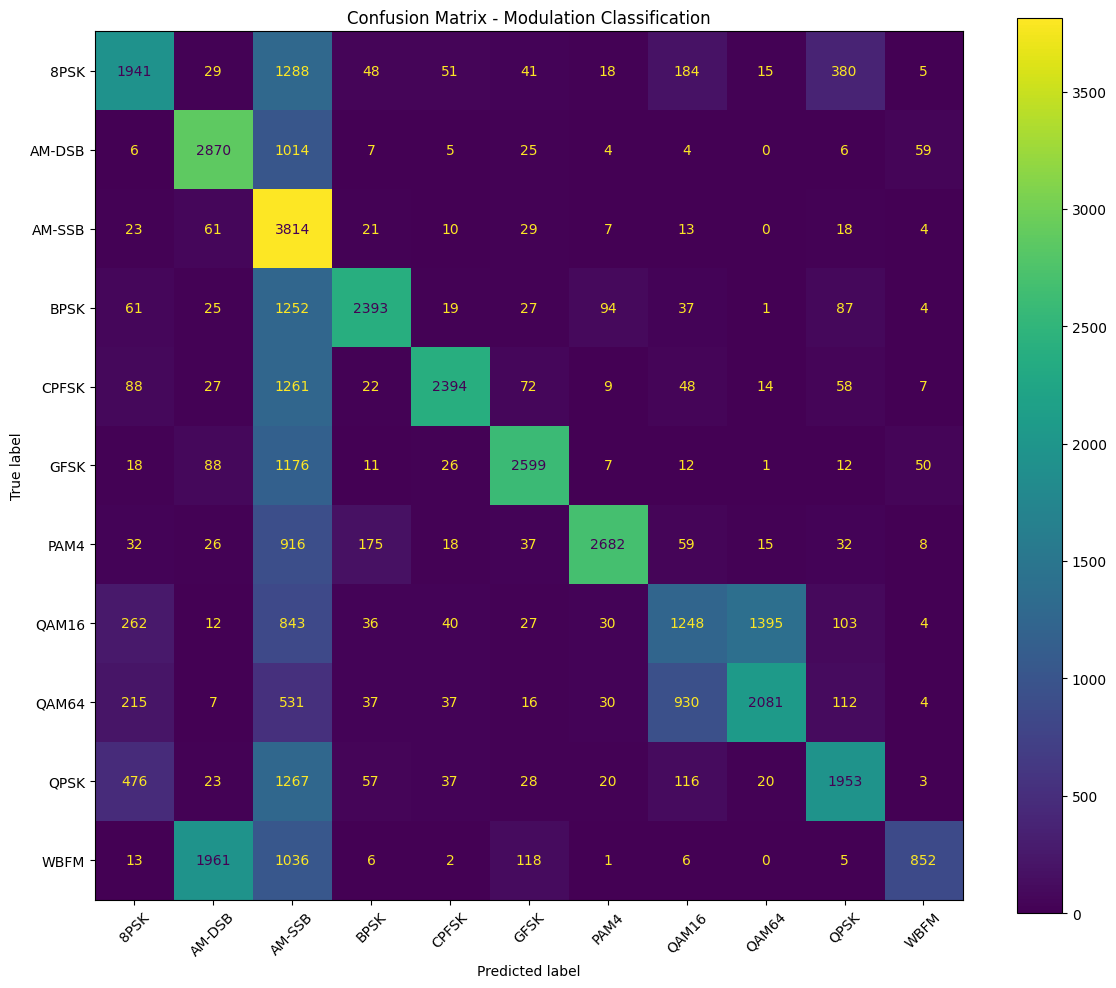


Confusion matrix saved:
E:\Major_project\AI-Based-Intelligent-RF-Spectrum-Signal-Identification-System-main\results\confusion_matrix.png


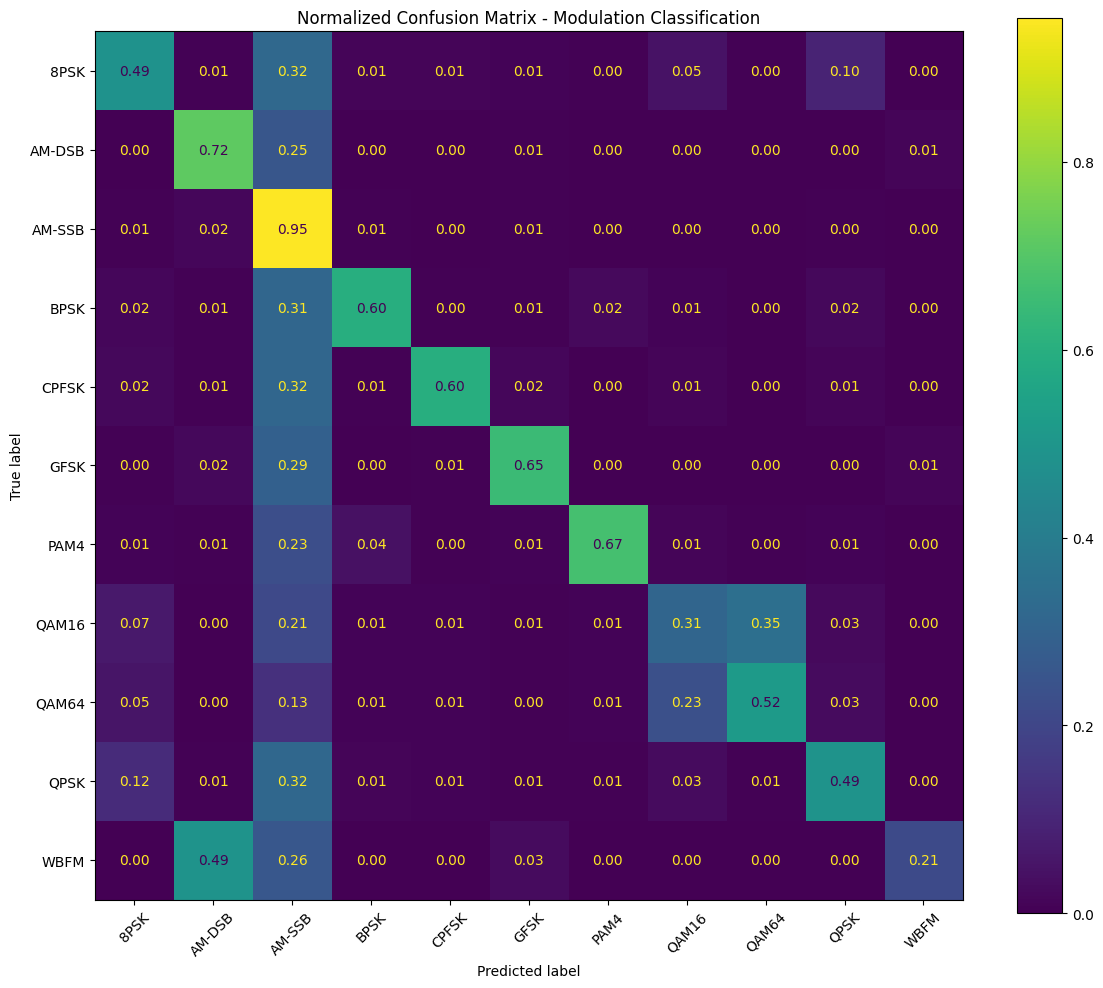


Normalized confusion matrix saved:
E:\Major_project\AI-Based-Intelligent-RF-Spectrum-Signal-Identification-System-main\results\normalized_confusion_matrix.png

ACCURACY VS SNR
SNR = -20 dB : 10.31%
SNR = -18 dB : 9.76%
SNR = -16 dB : 9.59%
SNR = -14 dB : 11.64%
SNR = -12 dB : 13.39%
SNR = -10 dB : 19.64%
SNR =  -8 dB : 33.49%
SNR =  -6 dB : 50.25%
SNR =  -4 dB : 64.27%
SNR =  -2 dB : 71.65%
SNR =   0 dB : 78.65%
SNR =   2 dB : 82.62%
SNR =   4 dB : 82.48%
SNR =   6 dB : 82.68%
SNR =   8 dB : 82.63%
SNR =  10 dB : 85.25%
SNR =  12 dB : 84.23%
SNR =  14 dB : 83.43%
SNR =  16 dB : 85.06%
SNR =  18 dB : 85.50%


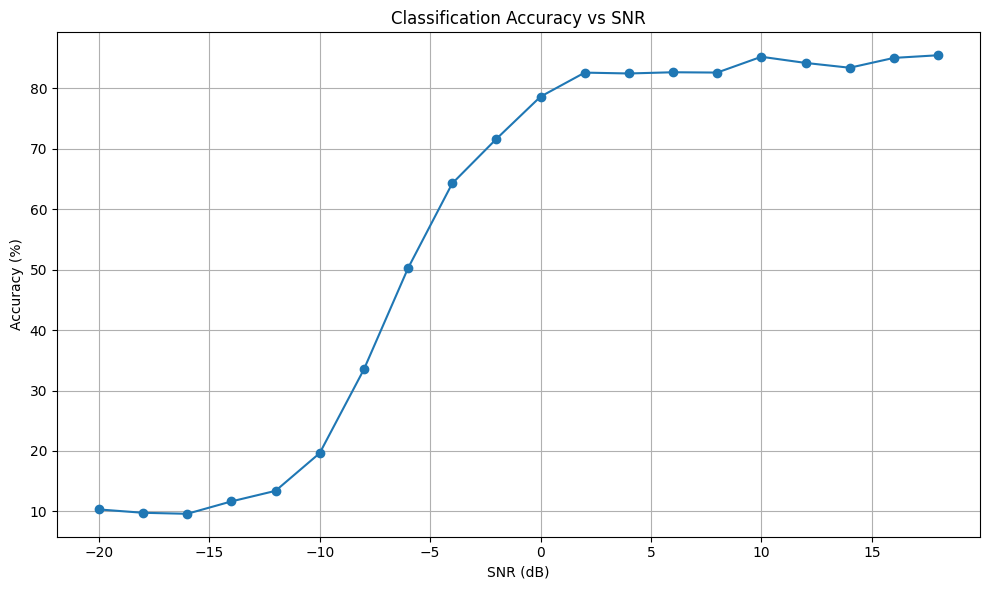


Accuracy vs SNR graph saved:
E:\Major_project\AI-Based-Intelligent-RF-Spectrum-Signal-Identification-System-main\results\accuracy_vs_snr.png

HIGH SNR PERFORMANCE
SNR >= 0 dB Accuracy: 83.24%
SNR < 0 dB Accuracy: 29.51%

PREDICTION STATISTICS
Correct Predictions: 24827
Incorrect Predictions: 19173
Average Prediction Confidence: 57.86%
Average Confidence for Correct Predictions: 73.87%
Average Confidence for Incorrect Predictions: 37.11%

SAMPLE PREDICTIONS

Sample 1
Actual:    QAM64
Predicted: QAM64
Confidence: 62.28%
SNR: 14 dB
Result: CORRECT

Sample 2
Actual:    WBFM
Predicted: WBFM
Confidence: 33.46%
SNR: -8 dB
Result: CORRECT

Sample 3
Actual:    QPSK
Predicted: QPSK
Confidence: 100.00%
SNR: 12 dB
Result: CORRECT

Sample 4
Actual:    QPSK
Predicted: 8PSK
Confidence: 25.68%
SNR: -2 dB
Result: INCORRECT

Sample 5
Actual:    PAM4
Predicted: PAM4
Confidence: 100.00%
SNR: 2 dB
Result: CORRECT

Sample 6
Actual:    AM-DSB
Predicted: AM-SSB
Confidence: 23.64%
SNR: -12 dB
Result: INCORREC

In [1]:
# ============================================================
# AI Based Intelligent RF Spectrum Signal Identification System
# Notebook: 06_model_evaluation.ipynb
# Purpose: Detailed Evaluation of CNN Modulation Classifier
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

print("=" * 70)
print("CNN MODEL EVALUATION")
print("=" * 70)


# ============================================================
# 1. DEFINE PATHS
# ============================================================

processed_data_dir = "../data/processed"
models_dir = "../models"
results_dir = "../results"

os.makedirs(results_dir, exist_ok=True)

model_path = os.path.join(
    models_dir,
    "best_cnn_modulation_classifier.keras"
)

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Best trained model not found:\n{os.path.abspath(model_path)}"
    )

print("\nModel found:")
print(os.path.abspath(model_path))


# ============================================================
# 2. LOAD TEST DATA
# ============================================================

print("\nLoading test data...")

X_test = np.load(
    os.path.join(processed_data_dir, "X_test.npy")
)

y_test = np.load(
    os.path.join(processed_data_dir, "y_test.npy")
)

snr_test = np.load(
    os.path.join(processed_data_dir, "snr_test.npy")
)

modulation_classes = np.load(
    os.path.join(
        processed_data_dir,
        "modulation_classes.npy"
    )
)

print("Test data loaded successfully.")

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of classes:", len(modulation_classes))


# ============================================================
# 3. PREPARE DATA FOR CNN
# ============================================================

X_test_cnn = X_test[..., np.newaxis]

print("\nCNN test input shape:")
print(X_test_cnn.shape)


# ============================================================
# 4. LOAD TRAINED MODEL
# ============================================================

print("\nLoading trained CNN model...")

model = tf.keras.models.load_model(model_path)

print("Trained model loaded successfully.")


# ============================================================
# 5. MAKE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING PREDICTIONS")
print("=" * 70)

prediction_probabilities = model.predict(
    X_test_cnn,
    batch_size=256,
    verbose=1
)

y_pred = np.argmax(
    prediction_probabilities,
    axis=1
)

prediction_confidence = np.max(
    prediction_probabilities,
    axis=1
)

print("\nPredictions generated successfully.")

print("Prediction shape:", y_pred.shape)


# ============================================================
# 6. CALCULATE OVERALL ACCURACY
# ============================================================

overall_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("OVERALL TEST ACCURACY")
print("=" * 70)

print(
    f"Overall Accuracy: "
    f"{overall_accuracy * 100:.2f}%"
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    y_test,
    y_pred,
    target_names=modulation_classes,
    digits=4
)

print(report)


# Save classification report
report_path = os.path.join(
    results_dir,
    "classification_report.txt"
)

with open(report_path, "w") as file:
    file.write(report)

print("\nClassification report saved:")
print(os.path.abspath(report_path))


# ============================================================
# 8. PRECISION, RECALL AND F1 SCORE
# ============================================================

precision, recall, f1_score, support = (
    precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=np.arange(len(modulation_classes)),
        zero_division=0
    )
)

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE")
print("=" * 70)

for i, modulation in enumerate(modulation_classes):

    print(f"\n{modulation}")

    print(
        f"Precision: {precision[i] * 100:.2f}%"
    )

    print(
        f"Recall:    {recall[i] * 100:.2f}%"
    )

    print(
        f"F1-Score:  {f1_score[i] * 100:.2f}%"
    )

    print(
        f"Support:   {support[i]}"
    )


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("GENERATING CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modulation_classes
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True
)

plt.title("Confusion Matrix - Modulation Classification")

plt.tight_layout()

confusion_matrix_path = os.path.join(
    results_dir,
    "confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix saved:")
print(os.path.abspath(confusion_matrix_path))


# ============================================================
# 10. NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

display_normalized = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=modulation_classes
)

display_normalized.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    values_format=".2f"
)

plt.title(
    "Normalized Confusion Matrix - Modulation Classification"
)

plt.tight_layout()

normalized_cm_path = os.path.join(
    results_dir,
    "normalized_confusion_matrix.png"
)

plt.savefig(
    normalized_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nNormalized confusion matrix saved:")
print(os.path.abspath(normalized_cm_path))


# ============================================================
# 11. ACCURACY AT EACH SNR LEVEL
# ============================================================

print("\n" + "=" * 70)
print("ACCURACY VS SNR")
print("=" * 70)

unique_snr_values = sorted(
    np.unique(snr_test)
)

snr_accuracy = []

for snr in unique_snr_values:

    indices = np.where(
        snr_test == snr
    )[0]

    snr_true = y_test[indices]
    snr_pred = y_pred[indices]

    accuracy = accuracy_score(
        snr_true,
        snr_pred
    )

    snr_accuracy.append(accuracy)

    print(
        f"SNR = {snr:>3} dB : "
        f"{accuracy * 100:.2f}%"
    )


# ============================================================
# 12. PLOT ACCURACY VS SNR
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    unique_snr_values,
    np.array(snr_accuracy) * 100,
    marker="o"
)

plt.title("Classification Accuracy vs SNR")

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.tight_layout()

snr_accuracy_path = os.path.join(
    results_dir,
    "accuracy_vs_snr.png"
)

plt.savefig(
    snr_accuracy_path,
    dpi=300
)

plt.show()

print("\nAccuracy vs SNR graph saved:")
print(os.path.abspath(snr_accuracy_path))


# ============================================================
# 13. CALCULATE HIGH SNR ACCURACY
# ============================================================

high_snr_threshold = 0

high_snr_indices = np.where(
    snr_test >= high_snr_threshold
)[0]

high_snr_accuracy = accuracy_score(
    y_test[high_snr_indices],
    y_pred[high_snr_indices]
)

print("\n" + "=" * 70)
print("HIGH SNR PERFORMANCE")
print("=" * 70)

print(
    f"SNR >= {high_snr_threshold} dB Accuracy: "
    f"{high_snr_accuracy * 100:.2f}%"
)


# ============================================================
# 14. LOW SNR ACCURACY
# ============================================================

low_snr_indices = np.where(
    snr_test < high_snr_threshold
)[0]

low_snr_accuracy = accuracy_score(
    y_test[low_snr_indices],
    y_pred[low_snr_indices]
)

print(
    f"SNR < {high_snr_threshold} dB Accuracy: "
    f"{low_snr_accuracy * 100:.2f}%"
)


# ============================================================
# 15. CORRECT AND INCORRECT PREDICTIONS
# ============================================================

correct_indices = np.where(
    y_test == y_pred
)[0]

incorrect_indices = np.where(
    y_test != y_pred
)[0]

print("\n" + "=" * 70)
print("PREDICTION STATISTICS")
print("=" * 70)

print("Correct Predictions:", len(correct_indices))
print("Incorrect Predictions:", len(incorrect_indices))

print(
    "Average Prediction Confidence: "
    f"{np.mean(prediction_confidence) * 100:.2f}%"
)

if len(correct_indices) > 0:

    print(
        "Average Confidence for Correct Predictions: "
        f"{np.mean(prediction_confidence[correct_indices]) * 100:.2f}%"
    )

if len(incorrect_indices) > 0:

    print(
        "Average Confidence for Incorrect Predictions: "
        f"{np.mean(prediction_confidence[incorrect_indices]) * 100:.2f}%"
    )


# ============================================================
# 16. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

sample_count = 10

random_indices = np.random.choice(
    len(y_test),
    sample_count,
    replace=False
)

for i, index in enumerate(random_indices, start=1):

    actual_modulation = modulation_classes[
        y_test[index]
    ]

    predicted_modulation = modulation_classes[
        y_pred[index]
    ]

    confidence = (
        prediction_confidence[index] * 100
    )

    sample_snr = snr_test[index]

    result = (
        "CORRECT"
        if y_test[index] == y_pred[index]
        else "INCORRECT"
    )

    print(f"\nSample {i}")

    print(
        f"Actual:    {actual_modulation}"
    )

    print(
        f"Predicted: {predicted_modulation}"
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print(
        f"SNR: {sample_snr} dB"
    )

    print(
        f"Result: {result}"
    )


# ============================================================
# 17. SAVE SNR RESULTS
# ============================================================

snr_results_path = os.path.join(
    results_dir,
    "accuracy_vs_snr.txt"
)

with open(snr_results_path, "w") as file:

    file.write(
        "Classification Accuracy vs SNR\n"
    )

    file.write("=" * 50 + "\n\n")

    for snr, accuracy in zip(
        unique_snr_values,
        snr_accuracy
    ):

        file.write(
            f"SNR {snr} dB: "
            f"{accuracy * 100:.2f}%\n"
        )

    file.write("\n")

    file.write(
        f"Overall Accuracy: "
        f"{overall_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"High SNR Accuracy (>= 0 dB): "
        f"{high_snr_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"Low SNR Accuracy (< 0 dB): "
        f"{low_snr_accuracy * 100:.2f}%\n"
    )


# ============================================================
# 18. FINAL EVALUATION SUMMARY
# ============================================================

evaluation_summary_path = os.path.join(
    results_dir,
    "evaluation_summary.txt"
)

with open(evaluation_summary_path, "w") as file:

    file.write(
        "AI Based Intelligent RF Spectrum Signal Identification System\n"
    )

    file.write(
        "CNN Model Evaluation Summary\n"
    )

    file.write("=" * 60 + "\n\n")

    file.write(
        f"Overall Test Accuracy: "
        f"{overall_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"High SNR Accuracy (>= 0 dB): "
        f"{high_snr_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"Low SNR Accuracy (< 0 dB): "
        f"{low_snr_accuracy * 100:.2f}%\n"
    )

    file.write(
        f"Correct Predictions: {len(correct_indices)}\n"
    )

    file.write(
        f"Incorrect Predictions: {len(incorrect_indices)}\n"
    )

    file.write(
        f"Average Confidence: "
        f"{np.mean(prediction_confidence) * 100:.2f}%\n"
    )


# ============================================================
# 19. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("MODEL EVALUATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"\nOverall Accuracy: "
    f"{overall_accuracy * 100:.2f}%"
)

print(
    f"High SNR Accuracy (>= 0 dB): "
    f"{high_snr_accuracy * 100:.2f}%"
)

print(
    f"Low SNR Accuracy (< 0 dB): "
    f"{low_snr_accuracy * 100:.2f}%"
)

print("\nGenerated Results:")

print("- classification_report.txt")
print("- confusion_matrix.png")
print("- normalized_confusion_matrix.png")
print("- accuracy_vs_snr.png")
print("- accuracy_vs_snr.txt")
print("- evaluation_summary.txt")

print("\nNEXT STEP:")
print("Analyze the results and improve the model if required.")